# IND320 — Project Part 2

## 1. Verify the Spark–Cassandra connection

Run the cells below in order using the project’s Python 3.12 `.venv` kernel in VS Code. Docker Desktop and the `cassandra` container must be running.

This check writes three sample rows to a dedicated `ind320_setup.spark_connection_test` table and reads them back through Spark. Repeating the check updates the same three primary keys. The sample rows are setup data, not API data.

The connector and port follow the course [Cassandra notebook](https://github.com/khliland/IND320/blob/main/D2Dbook/2_Data_sources/2_Databases/3_Cassandra.ipynb) and [Spark notebook](https://github.com/khliland/IND320/blob/main/D2Dbook/2_Data_sources/2_Databases/4_Spark.ipynb).

### 1.1 Check Python and select Java 17
Restart the notebook kernel before this cell if a Spark session is already running.

In [4]:
import os
import platform
import subprocess
import sys
from pathlib import Path

# The course setup uses Python 3.12 and Spark 3.5.1 with Java 17.
assert sys.version_info[:2] == (3, 12), "Select the project's Python 3.12 .venv kernel."
if platform.system() == "Darwin":
    os.environ["JAVA_HOME"] = subprocess.check_output(
        ["/usr/libexec/java_home", "-v", "17"], text=True
    ).strip()

# Spark's Python workers must use the same environment as this notebook.
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"

# Support launching the notebook from either the project root or notebooks/.
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
assert (project_root / "requirements.txt").exists(), "Open this notebook inside the project."
ivy_cache = project_root / "no_sync" / "spark_ivy"
ivy_cache.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version.split()[0])
print("Interpreter:", sys.executable)
print("Java home:", os.environ.get("JAVA_HOME", "not configured"))

Python: 3.12.14
Interpreter: /Users/agob/Projects/Streamlit_dashboard/.venv/bin/python
Java home: /Library/Java/JavaVirtualMachines/temurin-17.jdk/Contents/Home


### 1.2 Connect to Cassandra and prepare a test table
The Python driver creates the table structure. Spark will write and read the actual test rows.

In [5]:
from cassandra.cluster import Cluster

# Port 9042 is forwarded from Docker to this computer.
cluster = Cluster(["127.0.0.1"], port=9042, connect_timeout=10)
try:
    session = cluster.connect()
    version = session.execute("SELECT release_version FROM system.local").one()
    print("Cassandra connected:", version.release_version)

    # A single replica is sufficient for this local, single-container setup.
    session.execute("""
        CREATE KEYSPACE IF NOT EXISTS ind320_setup
        WITH replication = {'class': 'SimpleStrategy', 'replication_factor': 1}
    """)
    session.execute("""
        CREATE TABLE IF NOT EXISTS ind320_setup.spark_connection_test (
            run_id text,
            id int,
            area text,
            value double,
            PRIMARY KEY (run_id, id)
        )
    """)
    print("Test table ready.")
finally:
    # Release the Python driver's connections after preparing the table.
    cluster.shutdown()

NoHostAvailable: ('Unable to connect to any servers', {'127.0.0.1:9042': ConnectionRefusedError(61, "Tried connecting to [('127.0.0.1', 9042)]. Last error: Connection refused")})

### 1.3 Start Spark with the Cassandra connector
The first run downloads the connector and its Java dependencies. This can take a few minutes. Download messages and a native Hadoop library warning may appear.

In [ ]:
from pyspark.sql import SparkSession

# Match the connector version and configuration used in the course notebook.
spark = (
    SparkSession.builder
    .master("local[2]")
    .appName("IND320-Cassandra-Check")
    .config("spark.jars.packages", "com.datastax.spark:spark-cassandra-connector_2.12:3.5.1")
    .config("spark.jars.ivy", str(ivy_cache))
    .config("spark.cassandra.connection.host", "127.0.0.1")
    .config("spark.cassandra.connection.port", "9042")
    .config("spark.sql.extensions", "com.datastax.spark.connector.CassandraSparkExtensions")
    .config("spark.sql.catalog.mycatalog", "com.datastax.spark.connector.datasource.CassandraCatalog")
    .config("spark.ui.enabled", "false")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print("Spark connected:", spark.version)

### 1.4 Write sample rows using Spark

In [ ]:
# Fixed primary keys make this check safe to rerun without duplicate rows.
run_id = "setup-check"
sample_rows = [(run_id, 1, "NO1", 10.0), (run_id, 2, "NO2", 20.0), (run_id, 3, "NO3", 30.0)]
test_data = spark.createDataFrame(
    sample_rows, schema="run_id string, id int, area string, value double"
)
(
    test_data.write
    .format("org.apache.spark.sql.cassandra")
    .options(keyspace="ind320_setup", table="spark_connection_test")
    .mode("append")
    .save()
)
print("Spark wrote 3 sample rows to Cassandra.")

### 1.5 Read the rows back and verify the result

In [ ]:
# Read from Cassandra, rather than checking the original in-memory DataFrame.
from pyspark.sql import functions as F

stored_data = (
    spark.read
    .format("org.apache.spark.sql.cassandra")
    .options(keyspace="ind320_setup", table="spark_connection_test")
    .load()
    .filter(F.col("run_id") == run_id)
    .select("id", "area", "value")
    .orderBy("id")
)
actual = [(row.id, row.area, row.value) for row in stored_data.collect()]
expected = [(row[1], row[2], row[3]) for row in sample_rows]
assert actual == expected, f"Read-back mismatch: {actual}"
for row in actual:
    print(row)
print("PASS: Spark wrote to Cassandra and read back all 3 rows correctly.")

### 1.6 Stop the test session
This stops Spark. Cassandra remains running in Docker, and the test rows remain in the dedicated test table. To repeat the test, run the notebook from the top.

In [ ]:
# Free the local Spark resources when the check is finished.
spark.stop()
print("Spark stopped. Cassandra is still running in Docker.")

## 2. Verify the MongoDB connection and document storage

This section follows the [IND320 MongoDB notebook](https://github.com/khliland/IND320/blob/main/D2Dbook/2_Data_sources/2_Databases/5_MongoDB.ipynb): use PyMongo, ping the cluster, select a database and collection, insert a document, and read it back.

For this project, credentials are read from the local `.streamlit/secrets.toml` file using the same `[mongo]` / `uri` structure as Streamlit Cloud. This replaces the course notebook's `No_sync/MongoDB` credential file. Never paste credentials into notebook cells or outputs.

**Run section 2 on its own, from top to bottom.** It does not need Spark or the Cassandra container. Keep the project’s Python 3.12 `.venv` kernel selected.

The test writes at most one small document in `ind320_setup.connection_test`. A fixed `_id` prevents duplicate test documents. No API data or sample datasets are uploaded. The BSON-size check measures only this document, not database or index overhead. Larger imports must have a separate storage and transfer budget check against the Atlas Free limits.

### 2.1 Read Streamlit Secrets and ping MongoDB

In [6]:
from pathlib import Path
import tomllib

from pymongo import MongoClient
from pymongo.server_api import ServerApi

# Locate the project's ignored secrets file from either working directory.
mongo_project_root = Path.cwd()
if mongo_project_root.name == "notebooks":
    mongo_project_root = mongo_project_root.parent
mongo_secrets_path = mongo_project_root / ".streamlit" / "secrets.toml"

mongo_client = None
try:
    with mongo_secrets_path.open("rb") as secrets_file:
        mongo_uri = tomllib.load(secrets_file)["mongo"]["uri"]

    # Follow the course's MongoClient and Stable API setup.
    # Bound the connection pool and timeouts for this small test.
    mongo_client = MongoClient(
        mongo_uri,
        server_api=ServerApi("1"),
        serverSelectionTimeoutMS=10000,
        connectTimeoutMS=10000,
        socketTimeoutMS=10000,
        maxPoolSize=2,
    )
    del mongo_uri  # Do not display the URI in notebook outputs.
    assert mongo_client.admin.command("ping")["ok"] == 1
    print("PASS: Connected to MongoDB Atlas. Ping wrote no documents.")
except Exception:
    if mongo_client is not None:
        mongo_client.close()
    # Avoid printing driver errors that could contain connection details.
    raise RuntimeError(
        "MongoDB connection failed. Check the local secrets file, database credentials, "
        "and Atlas IP access list. Connection details are hidden."
    ) from None

PASS: Connected to MongoDB Atlas. Ping wrote no documents.


### 2.2 Insert one small document and read it back
Run this cell after 2.1. It closes the MongoDB client when finished. To repeat the check, rerun 2.1 and then 2.2.

In [7]:
from bson import BSON

# Use a dedicated setup collection and one fixed primary key.
# These are invented test values, not electricity or reservoir observations.
test_document = {
    "_id": "mongodb-connection-check",
    "purpose": "IND320 connection test",
    "value": 1,
}

try:
    # A strict size guard keeps this test payload below 1 KiB.
    document_bytes = len(BSON.encode(test_document))
    assert document_bytes <= 1024, "The setup document exceeds the test size limit."

    mongo_database = mongo_client["ind320_setup"]
    mongo_collection = mongo_database["connection_test"]
    test_filter = {"_id": test_document["_id"]}

    # The course uses insert_one. Check the fixed ID first so reruns add no copies.
    existing_document = mongo_collection.find_one(test_filter)
    if existing_document is None:
        mongo_collection.insert_one(test_document)
        print("Inserted one test document.")
    elif existing_document == test_document:
        print("The test document already exists; no additional document was inserted.")
    else:
        raise ValueError("An existing document uses the test ID; it was not changed.")

    # Fetch the persisted document from MongoDB and compare its full content.
    stored_document = mongo_collection.find_one(test_filter)
    assert stored_document == test_document, "The stored document differs from the input."
    print("Read back:", stored_document)
    print("Test document BSON size:", document_bytes, "bytes (excluding index/database overhead).")
    print("PASS: MongoDB stored and returned the test document correctly.")
except Exception:
    raise RuntimeError(
        "MongoDB write/read verification failed. Check the connection, write permissions, "
        "and any existing test document. Connection details are hidden."
    ) from None
finally:
    # Close the small connection pool after the test; Atlas stays available.
    mongo_client.close()

The test document already exists; no additional document was inserted.
Read back: {'_id': 'mongodb-connection-check', 'purpose': 'IND320 connection test', 'value': 1}
Test document BSON size: 86 bytes (excluding index/database overhead).
PASS: MongoDB stored and returned the test document correctly.


### 2.3 What this check demonstrates

A successful result verifies that Python can authenticate to Atlas and insert and retrieve a document. The test document remains in `ind320_setup.connection_test` and can be viewed in Atlas Data Explorer. Repeating the test reuses it.

This is a setup check only. The assignment still requires inserting the relevant Spark-extracted API data into MongoDB and querying those data from Streamlit. Review Atlas storage usage before any bulk import and avoid duplicate uploads.

## 3. Inspect a small NVE API sample

This section follows the HTTP GET and JSON workflow in the IND320 [API notebook](https://github.com/khliland/IND320/blob/main/D2Dbook/2_Data_sources/3_APIs/1_APIs.ipynb) and [REST notebook](https://github.com/khliland/IND320/blob/main/D2Dbook/2_Data_sources/3_APIs/2_REST.ipynb). We adapt the URL to NVE and turn the returned JSON into pandas tables. Unlike the course's testing example with `verify=False`, we retain Requests' default TLS certificate verification. We also add timeouts and a response-size guard to control resource use.

Run section 3 independently, from top to bottom. It needs no credentials, Spark session, or database connection.

**Scope:** two small GET requests: the latest published week and the area metadata. We do not download the full historical dataset or write to Cassandra/MongoDB. Each response is limited to 128 KiB of decoded JSON; the complete section has a 256 KiB JSON-body budget. Notebook outputs retain only these small tables. Rerunning the download cell makes two new requests.

Sources: [NVE Swagger/API schema](https://biapi.nve.no/magasinstatistikk/swagger/index.html), [NVE API description](https://api.nve.no/doc/magasinstatistikk/), and [About reservoir statistics](https://www.nve.no/energi/analyser-og-statistikk/om-magasinstatistikken/). NVE data are provided under NLOD, compatible with CC BY 3.0 Norway; credit NVE when using the data.

### 3.1 Fetch the latest week and area descriptions

In [8]:
import json
from datetime import datetime, timezone

import pandas as pd
import requests
from IPython.display import display

NVE_BASE_URL = "https://biapi.nve.no/magasinstatistikk/api/Magasinstatistikk/"
NVE_RESPONSE_LIMIT = 128 * 1024
NVE_SMALL_ENDPOINTS = {"HentOffentligDataSisteUke", "HentOmråder"}


def fetch_small_nve_json(endpoint):
    # Restrict this introductory check to the two small, documented endpoints.
    if endpoint not in NVE_SMALL_ENDPOINTS:
        raise ValueError("This sample helper only supports the two small NVE endpoints.")

    payload = bytearray()
    with requests.get(NVE_BASE_URL + endpoint, timeout=(10, 30), stream=True) as response:
        response.raise_for_status()
        # Stop reading if the decoded body exceeds the per-response budget.
        for chunk in response.iter_content(chunk_size=4096):
            if len(payload) + len(chunk) > NVE_RESPONSE_LIMIT:
                raise RuntimeError("NVE response exceeded the 128 KiB sample budget.")
            payload.extend(chunk)

    return json.loads(payload), len(payload)


nve_latest_json, nve_latest_bytes = fetch_small_nve_json("HentOffentligDataSisteUke")
nve_areas_json, nve_areas_bytes = fetch_small_nve_json("HentOmråder")
assert isinstance(nve_latest_json, list) and nve_latest_json, "Expected weekly observations."
assert isinstance(nve_areas_json, list) and nve_areas_json, "Expected a list of area-group objects."

print("Retrieved at (UTC):", datetime.now(timezone.utc).isoformat(timespec="seconds"))
print("Weekly observations:", len(nve_latest_json))
print("Latest-week JSON:", nve_latest_bytes, "bytes")
print("Area-metadata JSON:", nve_areas_bytes, "bytes")
print("Total decoded JSON:", nve_latest_bytes + nve_areas_bytes, "bytes (HTTP overhead excluded)")

Retrieved at (UTC): 2026-10-08T18:22:39+00:00
Weekly observations: 9
Latest-week JSON: 2474 bytes
Area-metadata JSON: 1734 bytes
Total decoded JSON: 4208 bytes (HTTP overhead excluded)


### 3.2 Inspect geographic coverage

The area type and number form a joint key. In this API, `EL` identifies the five electricity price areas, `NO` with number 0 identifies Norway as a whole, and `VASS` identifies the reservoir-statistics watercourse regions. For example, `EL` / 1 has the display name `NO 1`; it must not be confused with the `NO` area type.

We use NVE's returned names and geographic descriptions rather than inventing a mapping. The metadata can include areas for which the latest-week endpoint has no observation.

In [9]:
# HentOmråder returns a list whose objects contain land/elspot/vassdrag lists.
area_records = []
for grouped_areas in nve_areas_json:
    for group in ("land", "elspot", "vassdrag"):
        area_records.extend(grouped_areas.get(group) or [])

nve_areas = pd.DataFrame(area_records)
area_key = ["omrType", "omrnr"]
assert not nve_areas.duplicated(area_key).any(), "Duplicate NVE area keys."
nve_areas = nve_areas.sort_values(area_key).reset_index(drop=True)
with pd.option_context("display.max_colwidth", None):
    display(nve_areas[["omrType", "omrnr", "navn", "beskrivelse"]])

,omrType,omrnr,navn,beskrivelse
0,EL,1,NO 1,Sørøst-Norge. Omfatter østlige del av Østlandet fra Buskerud og nordover (bortsett fra den del av Innlandet som ligger vest og nord for Vågåmo).
1,EL,2,NO 2,"Sørvest-Norge. Omfatter mesteparten av Vestfold, Telemark, Agder, Rogaland og sørlige del av Vestland."
2,EL,3,NO 3,"Midt-Norge. Omfatter nordre og vestlige del av Vestland, den del av Innlandet som ligger vest og nord for Vågåmo, Møre og Romsdal og Trøndelag til Tunnsjødal."
3,EL,4,NO 4,Nord-Norge. Omfatter resten av Trøndelag og Nord-Norge.
4,EL,5,NO 5,"Vest-Norge. Omfatter midtre del av Vestland opp til Sognefjorden og Indre Sogn, og vestlig del av Buskerud."
5,NO,0,Norge,Hele landet
6,VASS,1,VASS1,"Sørøst-Norge. Østlandet, Agder og deler av Rogaland."
7,VASS,2,VASS2,Vest-Norge. Resten av Rogaland og Vestland.
8,VASS,3,VASS3,"Midt-Norge. Møre og Romsdal, Trøndelag og sørlige Nordland"
9,VASS,4,VASS4,Nord-Norge. Resten av Nordland og nordover.


### 3.3 Inspect fields, dates, and filling levels

- `dato_Id` is the observation date. Keep it separate from `neste_Publiseringsdato`, the next publication timestamp.
- `iso_aar` and `iso_uke` are ISO year and week. ISO year can differ from calendar year around New Year; preserve the API's ISO fields.
- As in Part 1, treat `0001-01-01T00:00:00` in the publication field as a missing-value marker.
- `fyllingsgrad` is a fraction: multiply by 100 for display as a percentage.
- `fylling_TWh` is stored energy, while `kapasitet_TWh` is capacity.

The API's date strings here contain no UTC offset. We parse them as supplied, without silently assuming they are UTC. The UTC timestamp printed in 3.1 records when we fetched the response, not when the reservoir observation was made.

In [10]:
nve_latest = pd.DataFrame(nve_latest_json)
required_fields = {
    "dato_Id", "omrType", "omrnr", "iso_aar", "iso_uke", "fyllingsgrad",
    "fylling_TWh", "kapasitet_TWh", "neste_Publiseringsdato",
}
assert required_fields.issubset(nve_latest.columns), "The expected NVE schema has changed."
print("Returned fields:", ", ".join(nve_latest.columns))

# Use explicit names to keep observation and publication times separate.
nve_latest["observation_date"] = pd.to_datetime(nve_latest["dato_Id"], errors="raise")
publication_values = nve_latest["neste_Publiseringsdato"].replace(
    "0001-01-01T00:00:00", pd.NA
)
nve_latest["next_publication_date"] = pd.to_datetime(publication_values, errors="raise")
nve_latest["filling_percent"] = nve_latest["fyllingsgrad"] * 100
assert not nve_latest.duplicated(["observation_date", *area_key]).any(), "Duplicate weekly observations."

# Check ISO fields against each observation date, without using calendar year.
iso_dates = nve_latest["observation_date"].dt.isocalendar()
assert (iso_dates["year"] == nve_latest["iso_aar"]).all(), "ISO year mismatch."
assert (iso_dates["week"] == nve_latest["iso_uke"]).all(), "ISO week mismatch."

# Join on BOTH area fields; numbers overlap across area types.
nve_preview = nve_latest.merge(
    nve_areas[[*area_key, "navn"]], on=area_key, how="left", validate="many_to_one"
).sort_values(area_key)
assert nve_preview["navn"].notna().all(), "An observation has no matching area description."
display(nve_preview[[
    "observation_date", "iso_aar", "iso_uke", "omrType", "omrnr", "navn",
    "filling_percent", "fylling_TWh", "kapasitet_TWh", "next_publication_date",
]].round({"filling_percent": 2, "fylling_TWh": 3, "kapasitet_TWh": 3}))

# Report missing coverage explicitly; do not invent zero-valued observations.
observed_keys = set(map(tuple, nve_latest[area_key].to_numpy()))
metadata_keys = set(map(tuple, nve_areas[area_key].to_numpy()))
print("Areas in metadata without a latest-week row:", sorted(metadata_keys - observed_keys))
print("PASS: Small NVE sample fetched; schema, dates and area mapping checked.")
print("Database writes: 0. Full historical downloads: 0.")

Returned fields: dato_Id, omrType, omrnr, iso_aar, iso_uke, fyllingsgrad, kapasitet_TWh, fylling_TWh, neste_Publiseringsdato, fyllingsgrad_forrige_uke, endring_fyllingsgrad


,observation_date,iso_aar,iso_uke,omrType,omrnr,navn,filling_percent,fylling_TWh,kapasitet_TWh,next_publication_date
1,2026-10-04,2026,40,EL,1,NO 1,75.14,4.511,6.003,2026-10-14 13:00:00
0,2026-10-04,2026,40,EL,2,NO 2,51.23,17.439,34.044,2026-10-14 13:00:00
3,2026-10-04,2026,40,EL,3,NO 3,71.87,6.411,8.921,2026-10-14 13:00:00
2,2026-10-04,2026,40,EL,4,NO 4,89.44,18.853,21.079,2026-10-14 13:00:00
4,2026-10-04,2026,40,EL,5,NO 5,70.93,12.335,17.391,2026-10-14 13:00:00
5,2026-10-04,2026,40,NO,0,Norge,67.89,59.358,87.438,2026-10-14 13:00:00
7,2026-10-04,2026,40,VASS,1,VASS1,61.58,22.197,36.044,2026-10-14 13:00:00
8,2026-10-04,2026,40,VASS,2,VASS2,58.74,13.650,23.238,2026-10-14 13:00:00
6,2026-10-04,2026,40,VASS,3,VASS3,84.20,23.705,28.155,2026-10-14 13:00:00


Areas in metadata without a latest-week row: [('VASS', 4)]
PASS: Small NVE sample fetched; schema, dates and area mapping checked.
Database writes: 0. Full historical downloads: 0.


### 3.4 Limits of this sample and the next step

One week is enough to inspect the response structure and area mapping, but not to recreate the historical line plots from Part 1. The Swagger schema inspected for this step documents no date-range parameters for `HentOffentligData` or `HentOffentligDataSisteUke`. Filtering a DataFrame after downloading is not the same as restricting the API download itself. We must account for that when designing the assignment's interval control and caching.

Section 4 implements a bounded historical retrieval and recreates the Part 1 plots from API data. The existing CSV-based app is still the Part 1 implementation; this small API check does not yet replace it.

## 4. Recreate Part 1 plots from the NVE API

The assignment requires replacing the reservoir CSV input with a direct API connection and recreating the associated Part 1 plots. This section recreates all 13 Part 1 figures: the publication-date investigation, five category/calendar figures, five separate measurement figures, and two combined measurement figures.

**Comparison period:** 8 January 1995–6 September 2026, matching the Part 1 snapshot. The endpoint may return newer observations; we report the full API coverage but limit the plots to the original comparison period. Live API revisions can cause differences from the older CSV.

**Download and storage plan:** NVE's [Swagger schema](https://biapi.nve.no/magasinstatistikk/swagger/v1/swagger.json) documents no date-range parameters for `HentOffentligData`. Its HEAD response did not provide a size estimate (HTTP 405 during setup). We therefore read the response incrementally with an **8 MiB decoded-body limit**, bounded connection/read timeouts, and no automatic retry loop. This is a local budget chosen for this project, not an NVE service quota. Requests retains TLS certificate verification.

A successful response is saved once under the Git-ignored `no_sync/nve_cache/` directory and reused. Set `REFRESH_NVE_HISTORY = True` explicitly to replace the snapshot; leave it False otherwise. The download time is printed so that a cached snapshot is never presented as freshly retrieved. The cache contains public NVE data only. **No Cassandra or MongoDB writes occur.** The DataFrame and figure outputs require additional local memory/storage beyond the raw JSON.

Run section 4 independently from top to bottom using the project `.venv`. No credentials or running database are required. The source is the NVE API (or its local API-response cache), not the Part 1 CSV. The existing Streamlit pages will be migrated separately.

### 4.1 Download once, with a size limit, and reuse the API snapshot

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import json

import requests
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display

# Keep this comparison reproducible and do not refresh on every notebook run.
REFRESH_NVE_HISTORY = False
MAX_HISTORY_BYTES = 8 * 1024 * 1024
HISTORY_URL = "https://biapi.nve.no/magasinstatistikk/api/Magasinstatistikk/HentOffentligData"

history_root = Path.cwd()
if history_root.name == "notebooks":
    history_root = history_root.parent
assert (history_root / "requirements.txt").exists(), "Open the notebook inside the project."
history_cache = history_root / "no_sync" / "nve_cache" / "reservoir_history.json"


def load_nve_history_snapshot(refresh=False):
    # Reuse the cached API response; this is independent of the old CSV file.
    if history_cache.exists() and not refresh:
        if history_cache.stat().st_size > MAX_HISTORY_BYTES:
            raise ValueError("The existing API cache exceeds the 8 MiB budget.")
        payload = history_cache.read_bytes()
        source = "Local cache of the NVE API response (no new download)"
    else:
        payload = bytearray()
        with requests.get(HISTORY_URL, stream=True, timeout=(10, 45)) as response:
            response.raise_for_status()
            for chunk in response.iter_content(chunk_size=8192):
                if len(payload) + len(chunk) > MAX_HISTORY_BYTES:
                    raise RuntimeError("History exceeded the 8 MiB budget; download stopped.")
                payload.extend(chunk)
        source = "Direct NVE API download"

    # Validate the response before saving/replacing the local cache.
    records = json.loads(payload)
    if not isinstance(records, list) or not records:
        raise ValueError("Expected a non-empty JSON list from NVE.")
    required = {"dato_Id", "omrType", "omrnr", "fyllingsgrad", "neste_Publiseringsdato"}
    if any(not isinstance(row, dict) or not required.issubset(row) for row in records):
        raise ValueError("NVE history has an unexpected row structure.")
    if refresh or not history_cache.exists():
        history_cache.parent.mkdir(parents=True, exist_ok=True)
        temporary_cache = history_cache.with_suffix(".tmp")
        temporary_cache.write_bytes(payload)
        temporary_cache.replace(history_cache)

    snapshot_time = datetime.fromtimestamp(history_cache.stat().st_mtime, timezone.utc)
    return pd.DataFrame(records), len(payload), source, snapshot_time


history_raw, history_bytes, history_source, history_timestamp = load_nve_history_snapshot(
    refresh=REFRESH_NVE_HISTORY
)
print("Source:", history_source)
print("Snapshot saved at (UTC):", history_timestamp.isoformat(timespec="seconds"))
print(f"API response/cache: {history_bytes:,} bytes ({history_bytes / 1024**2:.2f} MiB)")
print(f"Rows returned: {len(history_raw):,}")
print("Full API date range:", history_raw["dato_Id"].min(), "to", history_raw["dato_Id"].max())
print("Database writes: 0")

Matplotlib is building the font cache; this may take a moment.


Source: Direct NVE API download
Snapshot saved at (UTC): 2026-10-08T19:10:40+00:00
API response/cache: 4,074,651 bytes (3.89 MiB)
Rows returned: 14,913
Full API date range: 1995-01-08 to 2026-10-04
Database writes: 0


### 4.2 Prepare the same variables and comparison period

We retain Part 1's English column names and the original observations. The year-1 publication marker becomes `NaT` only in the cleaned copy. Values slightly above 100% are reported rather than clipped. Area type and area number are used together; national time series use `NO` / 0 only.

ISO years/weeks are checked against observation dates. Publication times are kept distinct from observation dates, without assigning an undocumented time zone.

In [2]:
# The API DataFrame is the only data source for the reproduced figures.
# I rename the original Norwegian headers to make the API dataset easier to
# understand when I create tables, plots, and the Streamlit application.
english_names = {
    "dato_Id": "observation_date",
    "omrType": "area_type",
    "omrnr": "area_number",
    "iso_aar": "iso_year",
    "iso_uke": "iso_week",
    "fyllingsgrad": "filling_fraction",
    "kapasitet_TWh": "capacity_twh",
    "fylling_TWh": "stored_energy_twh",
    "neste_Publiseringsdato": "next_publication_date",
    "fyllingsgrad_forrige_uke": "previous_week_filling_fraction",
    "endring_fyllingsgrad": "weekly_filling_change"
}


history_all = history_raw.rename(columns=english_names).copy()
history_all["observation_date"] = pd.to_datetime(history_all["observation_date"], errors="raise")
assert not history_all.duplicated(["observation_date", "area_type", "area_number"]).any(), "Duplicate observation keys."
iso = history_all["observation_date"].dt.isocalendar()
assert (iso["year"] == history_all["iso_year"]).all(), "Unexpected ISO year."
assert (iso["week"] == history_all["iso_week"]).all(), "Unexpected ISO week."

# These fixed dates match Part 1; filtering happens AFTER the bounded download.
COMPARISON_START = pd.Timestamp("1995-01-08")
COMPARISON_END = pd.Timestamp("2026-09-06")
reservoirs = history_all.loc[
    history_all["observation_date"].between(COMPARISON_START, COMPARISON_END)
].sort_values(["observation_date", "area_type", "area_number"]).reset_index(drop=True)
assert not reservoirs.empty, "The API returned no rows for the comparison period."
assert reservoirs["observation_date"].min() == COMPARISON_START
assert reservoirs["observation_date"].max() == COMPARISON_END

year_one_date = "0001-01-01T00:00:00"
reservoirs_clean = reservoirs.copy()
reservoirs_clean["next_publication_date"] = pd.to_datetime(
    reservoirs_clean["next_publication_date"].replace(year_one_date, pd.NA), errors="raise"
)
measurement_columns = [
    "filling_fraction", "capacity_twh", "stored_energy_twh",
    "previous_week_filling_fraction", "weekly_filling_change",
]
measurement_labels = {
    "filling_fraction": "Filling fraction",
    "capacity_twh": "Capacity (TWh)",
    "stored_energy_twh": "Stored energy (TWh)",
    "previous_week_filling_fraction": "Previous-week filling fraction",
    "weekly_filling_change": "Weekly filling change",
}
assert not reservoirs_clean[measurement_columns].isna().any().any(), "Missing measurements require inspection."
national_data = reservoirs_clean.loc[
    (reservoirs_clean["area_type"] == "NO") & (reservoirs_clean["area_number"] == 0)
].sort_values("observation_date")
assert not national_data.empty and national_data["observation_date"].is_unique
national_dates = pd.DatetimeIndex(national_data["observation_date"])
expected_dates = pd.date_range(COMPARISON_START, COMPARISON_END, freq="W-SUN")
assert national_dates.equals(expected_dates), "Missing/unexpected national observation dates."

print(f"Comparison rows: {len(reservoirs_clean):,}; national weeks: {len(national_data):,}")
print("Missing publication timestamps:", reservoirs_clean["next_publication_date"].isna().sum())
print("Filling fractions above 100% (kept):", (reservoirs_clean["filling_fraction"] > 1).sum())
print("Largest energy relationship difference (TWh):", (
    reservoirs_clean["stored_energy_twh"] - reservoirs_clean["capacity_twh"] * reservoirs_clean["filling_fraction"]
).abs().max())
print("Largest weekly-change relationship difference:", (
    reservoirs_clean["weekly_filling_change"] - (
        reservoirs_clean["filling_fraction"] - reservoirs_clean["previous_week_filling_fraction"]
    )
).abs().max())
display(pd.crosstab(reservoirs_clean["area_type"], reservoirs_clean["area_number"]))


Comparison rows: 14,877; national weeks: 1,653
Missing publication timestamps: 11322
Filling fractions above 100% (kept): 3
Largest energy relationship difference (TWh): 1.1527989997262011e-05
Largest weekly-change relationship difference: 5.999999998923533e-08


area_number,0,1,2,3,4,5
area_type,,,,,,
EL,0,1653,1653,1653,1653,1653
NO,1653,0,0,0,0,0
VASS,0,1653,1653,1653,0,0


### 4.3 Recreate the publication-date investigation (figure 1)

This reproduces Part 1's two-panel figure from API data: the change from a year-1 marker to recorded publication dates, and the first twelve date pairs after that change. The displayed table counts the observation-to-publication intervals. The original marker is retained in the raw comparison table for this investigation.

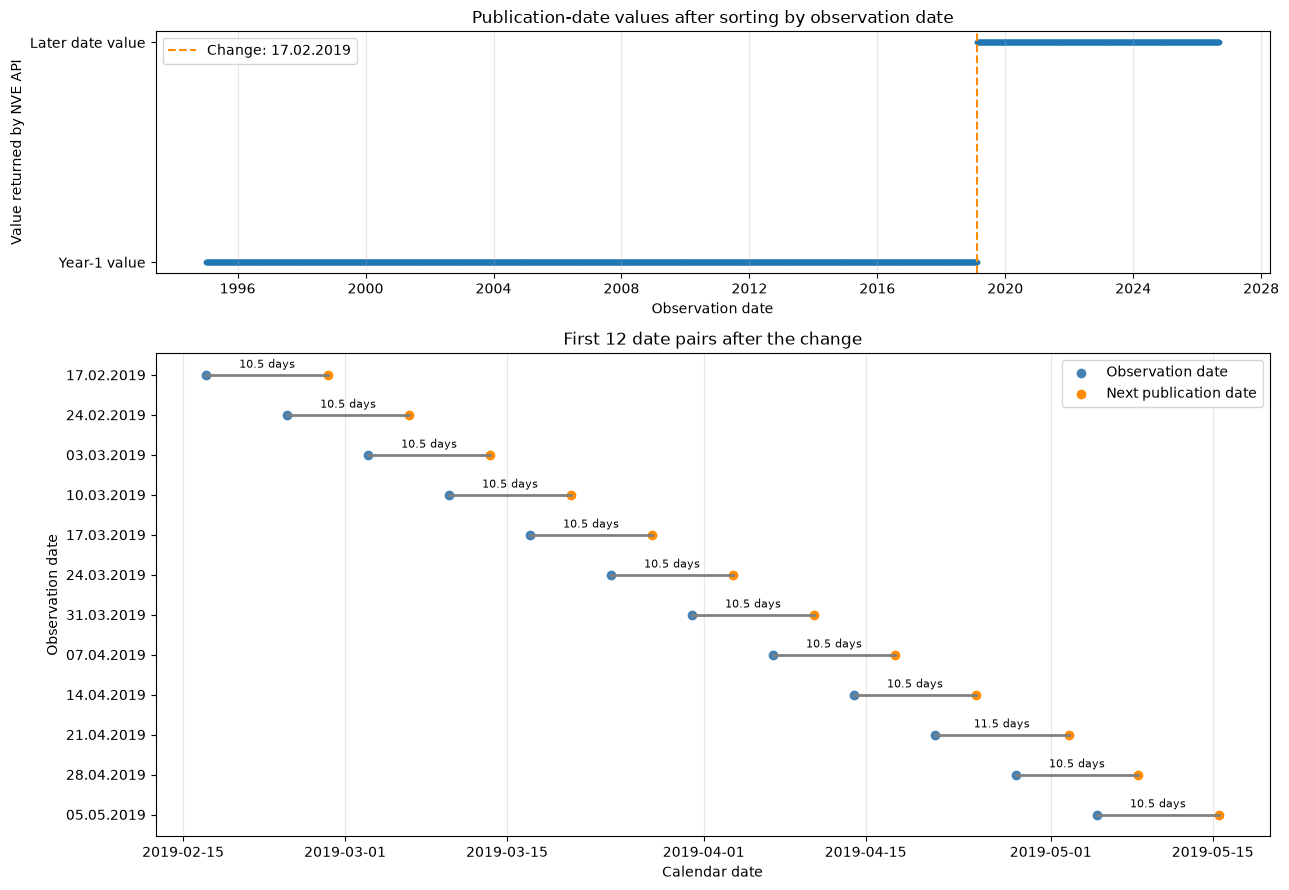

,days_between_dates,number_of_weeks
0,10.541667,390
1,11.541667,4
2,12.541667,1


In [3]:
# Build the same distinct date-pair table used in Part 1, now from API rows.
sorted_publication_dates = (
    reservoirs[["observation_date", "next_publication_date"]]
    .drop_duplicates()
    .sort_values("observation_date")
    .reset_index(drop=True)
)
assert (sorted_publication_dates["next_publication_date"] != year_one_date).any()
# I use the sorted table from the previous cell and convert only the dates
# that are later than year 1. The year-1 value stays untouched.
publication_pattern = sorted_publication_dates.copy()
publication_pattern["observation_date"] = pd.to_datetime(
    publication_pattern["observation_date"]
)
publication_pattern["date_group"] = (
    publication_pattern["next_publication_date"] != year_one_date
)

later_dates = publication_pattern[publication_pattern["date_group"]].copy()
later_dates["next_publication_date"] = pd.to_datetime(
    later_dates["next_publication_date"]
)
later_dates["days_between_dates"] = (
    later_dates["next_publication_date"]
    - later_dates["observation_date"]
).dt.total_seconds() / (24 * 60 * 60)

first_later_date = later_dates["observation_date"].min()
example_weeks = later_dates.head(12)

fig, axes = plt.subplots(
    2, 1, figsize=(13, 9),
    gridspec_kw={"height_ratios": [1, 2]}
)

# The first panel shows the exact point where the values change.
axes[0].scatter(
    publication_pattern["observation_date"],
    publication_pattern["date_group"].astype(int),
    s=10
)
axes[0].axvline(
    first_later_date, color="darkorange", linestyle="--",
    label=f"Change: {first_later_date:%d.%m.%Y}"
)
axes[0].set_yticks([0, 1], ["Year-1 value", "Later date value"])
axes[0].set_title("Publication-date values after sorting by observation date")
axes[0].set_xlabel("Observation date")
axes[0].set_ylabel("Value returned by NVE API")
axes[0].legend()
axes[0].grid(axis="x", alpha=0.3)

# The second panel connects the first twelve observation dates after the
# change to the corresponding next-publication dates.
for position, (_, row) in enumerate(example_weeks.iterrows()):
    axes[1].plot(
        [row["observation_date"], row["next_publication_date"]],
        [position, position], color="grey", linewidth=2
    )
    axes[1].scatter(
        row["observation_date"], position, color="steelblue",
        label="Observation date" if position == 0 else None
    )
    axes[1].scatter(
        row["next_publication_date"], position, color="darkorange",
        label="Next publication date" if position == 0 else None
    )
    middle = row["observation_date"] + (
        row["next_publication_date"] - row["observation_date"]
    ) / 2
    axes[1].text(
        middle, position - 0.18,
        f'{row["days_between_dates"]:.1f} days',
        ha="center", fontsize=8
    )

axes[1].set_yticks(
    range(len(example_weeks)),
    example_weeks["observation_date"].dt.strftime("%d.%m.%Y")
)
axes[1].invert_yaxis()
axes[1].set_title("First 12 date pairs after the change")
axes[1].set_xlabel("Calendar date")
axes[1].set_ylabel("Observation date")
axes[1].legend()
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()
plt.close(fig)

# This table counts the intervals for all date pairs after the change.
(
    later_dates["days_between_dates"]
    .value_counts().sort_index()
    .rename_axis("days_between_dates")
    .reset_index(name="number_of_weeks")
)

### 4.4 Recreate the category and calendar plots (figures 2–6)

These reproduce Part 1's observation-year, area-type, area-number, ISO-year, and ISO-week frequency plots. As in Part 1, the area-number figure pools numbers from different area types; it is an identifier-frequency check, not a comparison of distinct geographic regions. The cross-tabulation above retains that distinction.

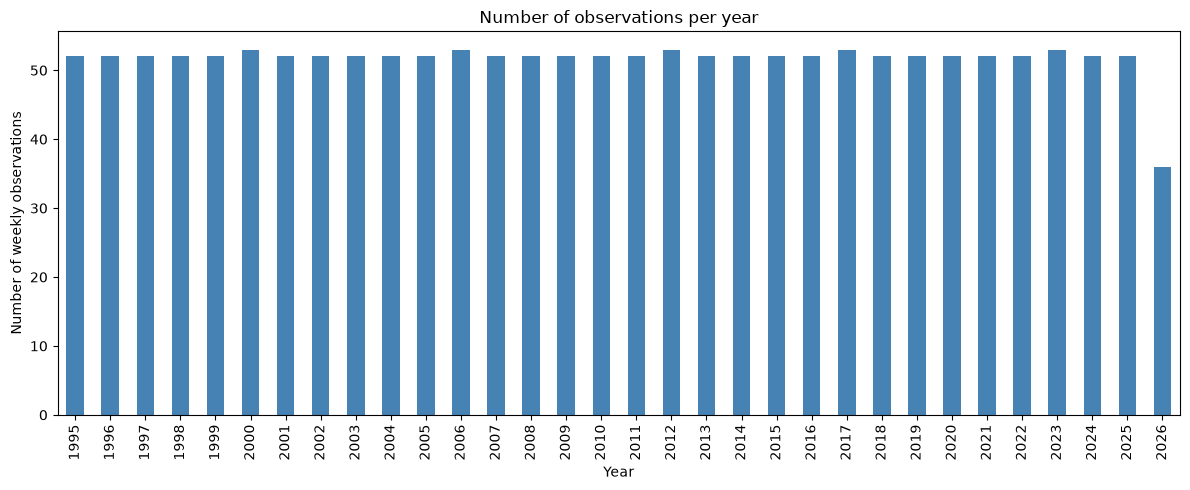

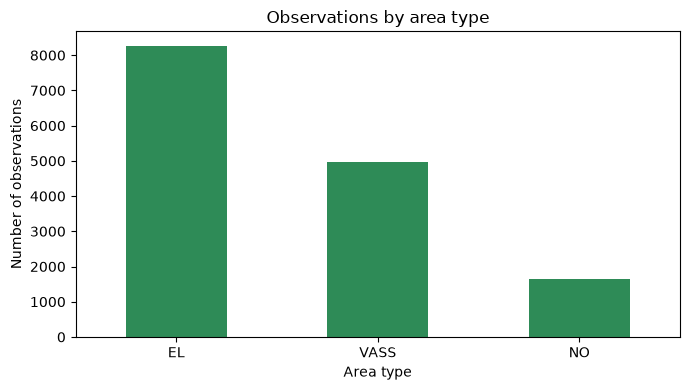

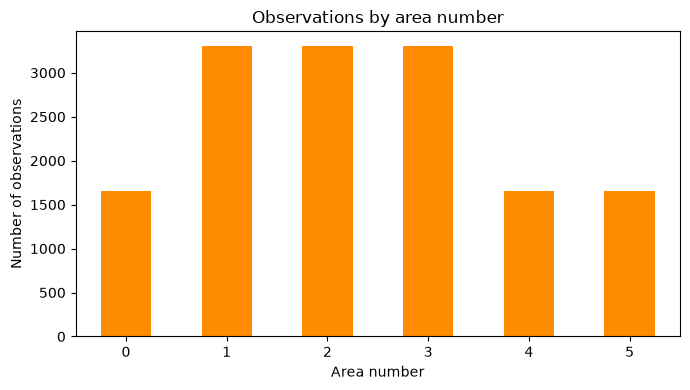

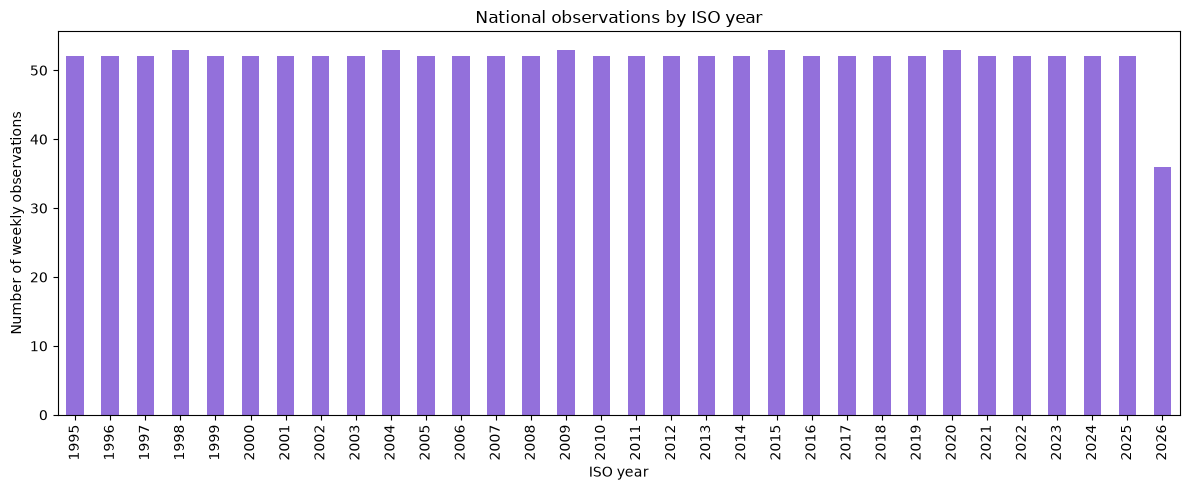

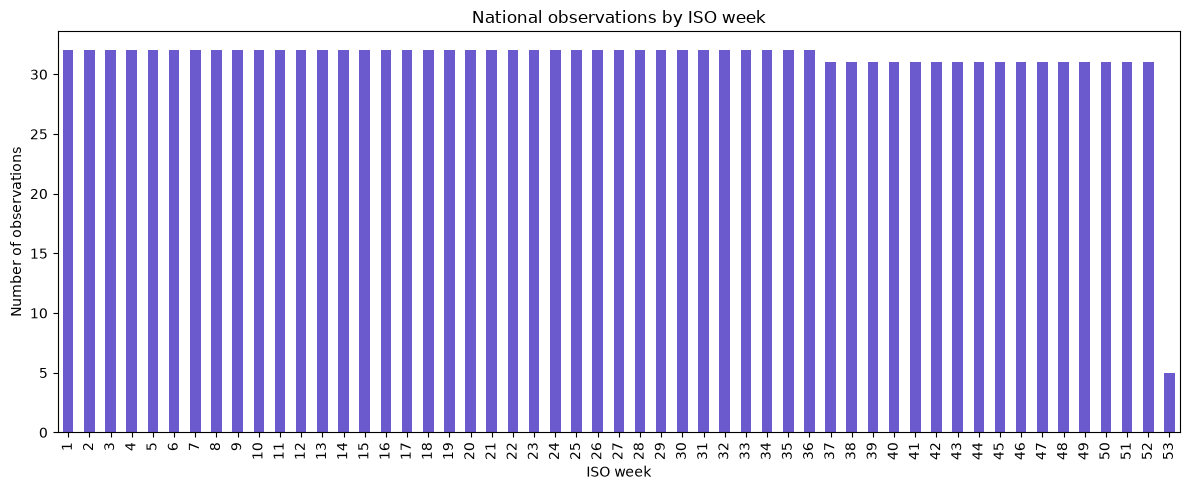

In [4]:
# observation_date: number of national observations recorded per year
observations_per_year = (
    national_data["observation_date"]
    .dt.year
    .value_counts()
    .sort_index()
)

observations_per_year.plot(
    kind="bar",
    figsize=(12, 5),
    color="steelblue"
)
plt.title("Number of observations per year")
plt.xlabel("Year")
plt.ylabel("Number of weekly observations")
plt.tight_layout()
plt.show()
plt.close()


# area_type: number of rows belonging to each geographical grouping
reservoirs_clean["area_type"].value_counts().plot(
    kind="bar",
    figsize=(7, 4),
    color="seagreen"
)
plt.title("Observations by area type")
plt.xlabel("Area type")
plt.ylabel("Number of observations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
plt.close()


# area_number: area numbers are reused across different area types
reservoirs_clean["area_number"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(7, 4),
    color="darkorange"
)
plt.title("Observations by area number")
plt.xlabel("Area number")
plt.ylabel("Number of observations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
plt.close()

# iso_year: number of national observations in each ISO year
national_data["iso_year"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(12, 5),
    color="mediumpurple"
)
plt.title("National observations by ISO year")
plt.xlabel("ISO year")
plt.ylabel("Number of weekly observations")
plt.tight_layout()
plt.show()
plt.close()


# iso_week: frequency of the different ISO week numbers
national_data["iso_week"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(12, 5),
    color="slateblue"
)
plt.title("National observations by ISO week")
plt.xlabel("ISO week")
plt.ylabel("Number of observations")
plt.tight_layout()
plt.show()
plt.close()

### 4.5 Recreate the five separate reservoir measurement plots (figures 7–11)

Each national measurement keeps its own axis and unit. Fractions are displayed as percentages. A change of 0.01 is one percentage point. We preserve slight overfilling values instead of forcing the series into a 0–100% range.

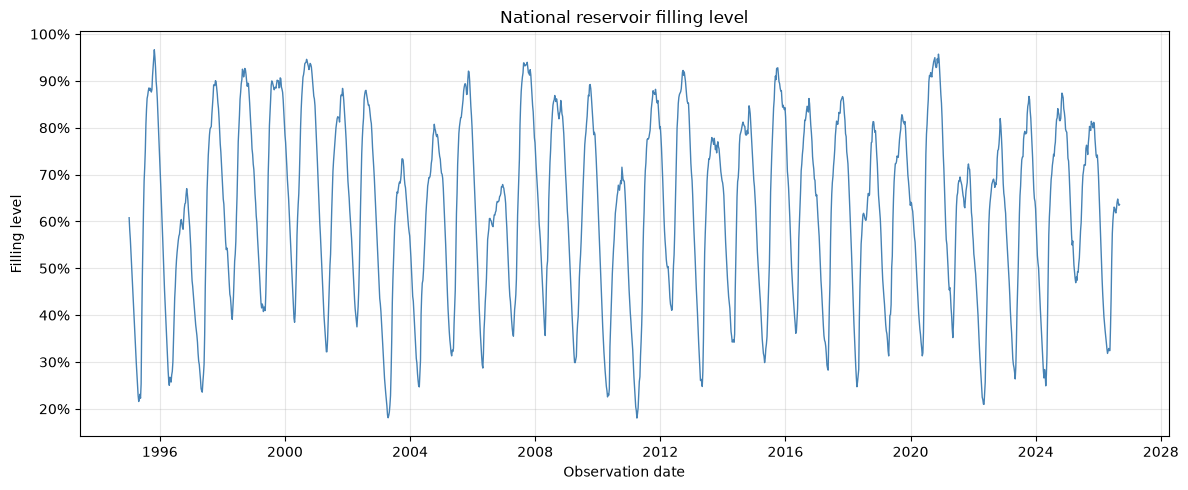

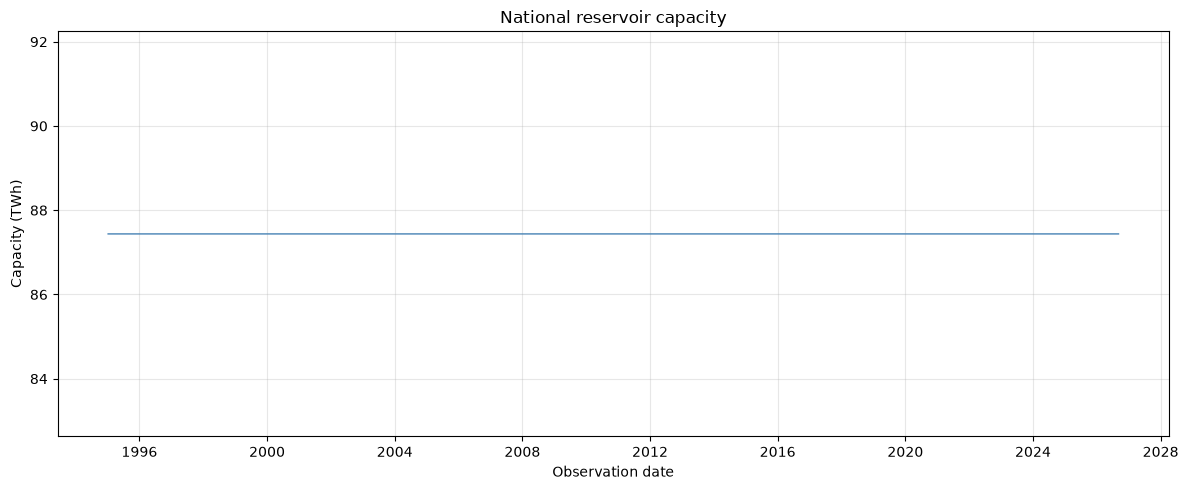

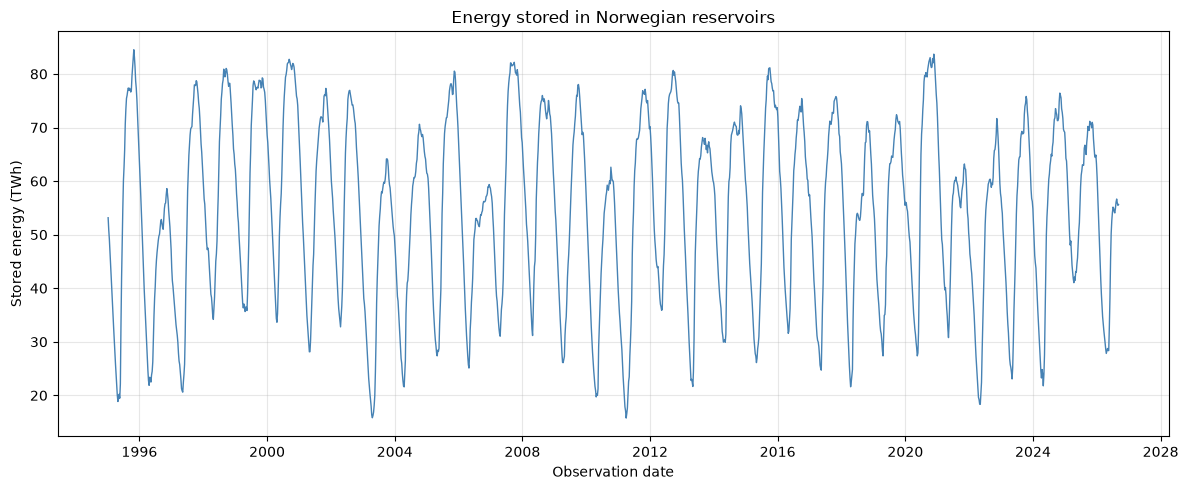

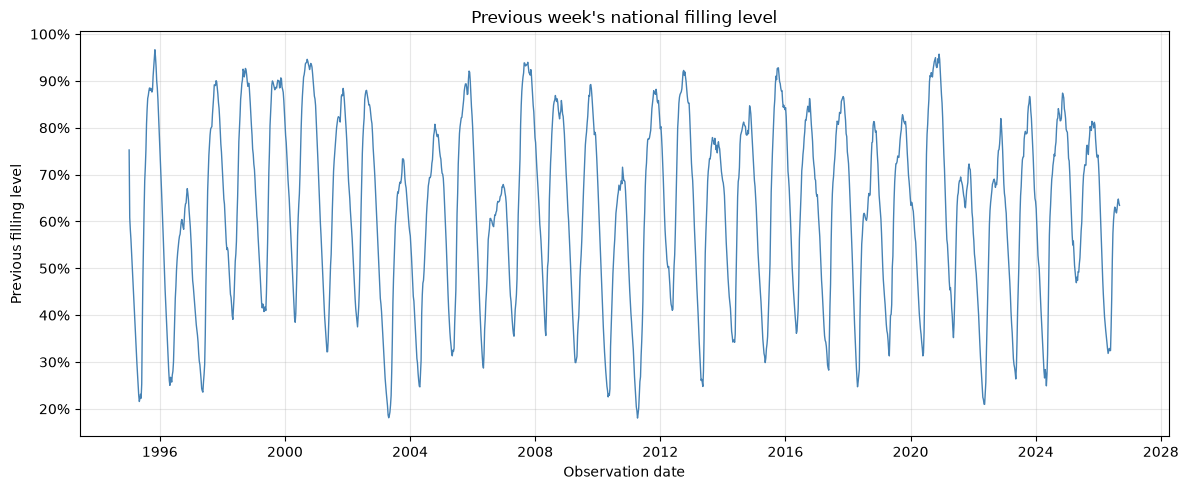

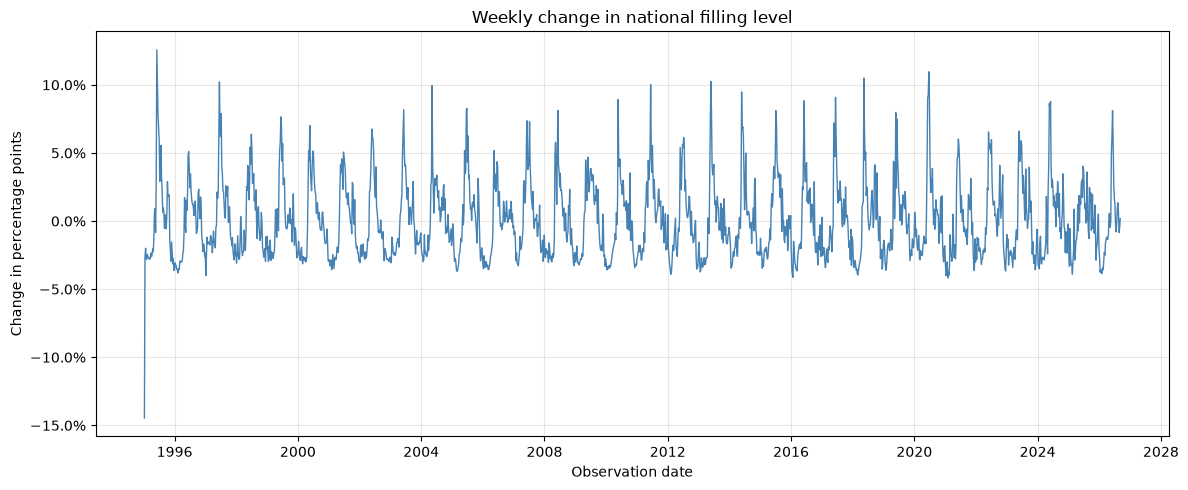

In [5]:
# Each measurement gets its own plot because the columns use different units
# and scales. The fraction columns are formatted as percentages without
# changing their underlying values.
measurement_plots = {
    "filling_fraction": {
        "title": "National reservoir filling level",
        "ylabel": "Filling level",
        "percentage": True
    },
    "capacity_twh": {
        "title": "National reservoir capacity",
        "ylabel": "Capacity (TWh)",
        "percentage": False
    },
    "stored_energy_twh": {
        "title": "Energy stored in Norwegian reservoirs",
        "ylabel": "Stored energy (TWh)",
        "percentage": False
    },
    "previous_week_filling_fraction": {
        "title": "Previous week's national filling level",
        "ylabel": "Previous filling level",
        "percentage": True
    },
    "weekly_filling_change": {
        "title": "Weekly change in national filling level",
        "ylabel": "Change in percentage points",
        "percentage": True
    }
}

for column, settings in measurement_plots.items():
    fig, axis = plt.subplots(figsize=(12, 5))

    axis.plot(
        national_data["observation_date"],
        national_data[column],
        color="steelblue",
        linewidth=1
    )

    axis.set_title(settings["title"])
    axis.set_xlabel("Observation date")
    axis.set_ylabel(settings["ylabel"])
    axis.grid(alpha=0.3)

    if settings["percentage"]:
        axis.yaxis.set_major_formatter(PercentFormatter(1.0))

    plt.tight_layout()
    plt.show()
    plt.close(fig)

### 4.6 Recreate the combined original-scale plot (figure 12)

This intentionally reproduces Part 1's comparison of mixed units. Its purpose is to expose the scale difference between TWh and fractions; the separate plots above should be used to read physical values.

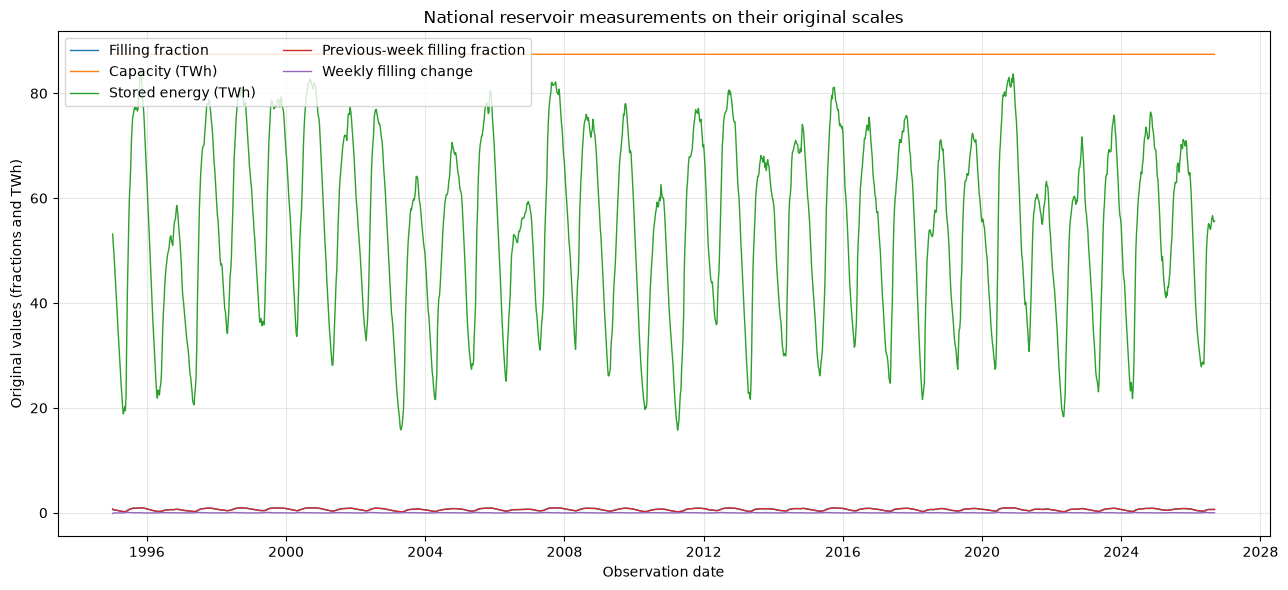

In [6]:
# I deliberately start with the original values so the scale problem is visible.
fig, axis = plt.subplots(figsize=(13, 6))

for column in measurement_columns:
    axis.plot(
        national_data["observation_date"],
        national_data[column],
        label=measurement_labels[column],
        linewidth=1
    )

axis.set_title("National reservoir measurements on their original scales")
axis.set_xlabel("Observation date")
axis.set_ylabel("Original values (fractions and TWh)")
axis.legend(loc="upper left", ncol=2)
axis.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.close(fig)

### 4.7 Recreate the min–max comparison (figure 13)

Scale each varying national measurement to 0–1 for shape comparison. Detect constant columns from the API data and exclude them to avoid division by zero. Scaling affects this figure only; original measurements remain unchanged.

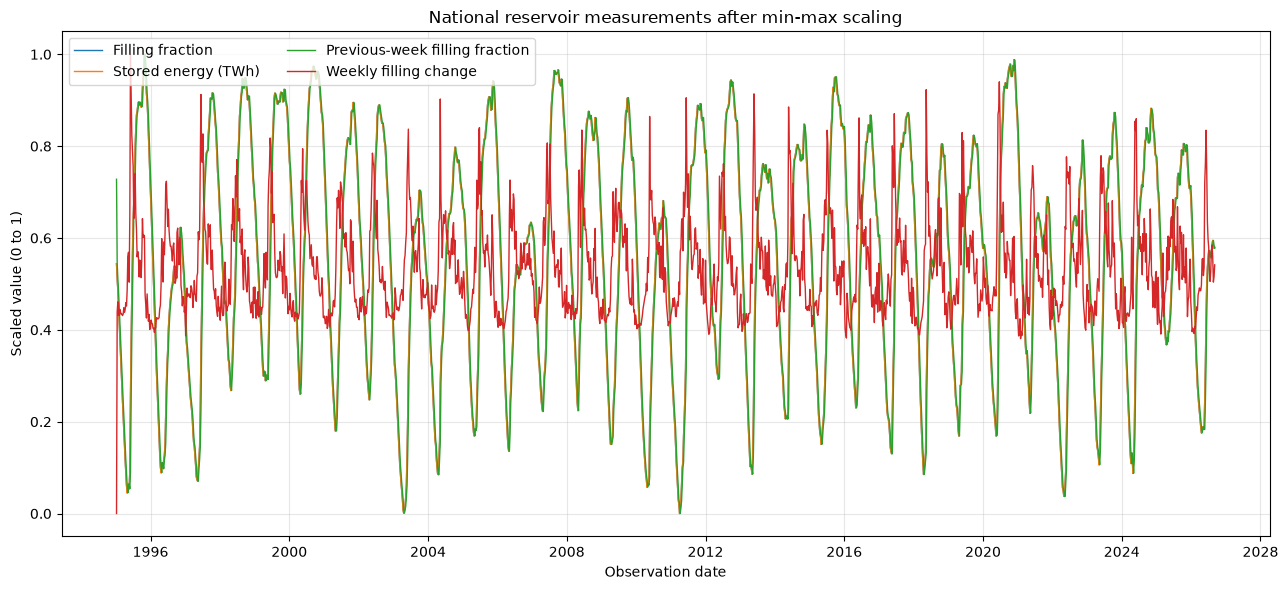

Excluded because the national series is constant: ['capacity_twh']


In [7]:
# Min-max scaling requires variation, so I automatically leave out columns
# that are constant. Constant columns are identified from this API snapshot.
changing_measurements = [
    column for column in measurement_columns
    if national_data[column].nunique() > 1
]

scaled_measurements = national_data[changing_measurements].apply(
    lambda column: (column - column.min()) / (column.max() - column.min())
)

fig, axis = plt.subplots(figsize=(13, 6))

for column in changing_measurements:
    axis.plot(
        national_data["observation_date"],
        scaled_measurements[column],
        label=measurement_labels[column],
        linewidth=1
    )

axis.set_title("National reservoir measurements after min-max scaling")
axis.set_xlabel("Observation date")
axis.set_ylabel("Scaled value (0 to 1)")
axis.legend(loc="upper left", ncol=2)
axis.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.close(fig)

excluded_columns = [
    column for column in measurement_columns
    if column not in changing_measurements
]
print("Excluded because the national series is constant:", excluded_columns)

### 4.8 Summarize the API-based reproduction

The figures use the same time window and plotting choices as Part 1, with the data source changed to NVE's API. The checks below report facts from this snapshot rather than copying historical counts from the old notebook. The incomplete final calendar year is caused by the selected cutoff date, not by missing earlier weeks.

**Snapshot finding (8 October 2026):** the comparison period contains 14,877 rows and 1,653 national weeks. The API-based sample has three filling fractions above 100%, while Part 1 recorded two. A development-time comparison with the original CSV identified EL / 1 on 22 October 2000: approximately 99.8831% in the CSV and 100.3412% in the API snapshot. We have not established the reason for this source difference and retain the API value unchanged. The notebook does not need to read the CSV to run this section.

The year-1 publication marker occurs in 11,322 comparison rows; the first observation date with a recorded publication timestamp remains 17 February 2019. National capacity is still constant in this snapshot and is excluded from min–max scaling. All 13 figures were executed and visually checked.

In [8]:
# Report current findings directly from the API-derived comparison data.
first_recorded_publication = reservoirs_clean.loc[
    reservoirs_clean["next_publication_date"].notna(), "observation_date"
].min()
print("First observation with a recorded next-publication date:", first_recorded_publication.date())
print("Comparison cutoff:", COMPARISON_END.date())
print("National columns excluded from min-max scaling:", excluded_columns)
print("PASS: 13 Part 1 figures recreated using API data for the original date range.")
print("CSV reads in this section: 0; database writes: 0.")

First observation with a recorded next-publication date: 2019-02-17
Comparison cutoff: 2026-09-06
National columns excluded from min-max scaling: ['capacity_twh']
PASS: 13 Part 1 figures recreated using API data for the original date range.
CSV reads in this section: 0; database writes: 0.


## AI usage — setup draft

Codex helped create and check this setup notebook, using the course Cassandra, Spark, MongoDB, and API examples together with NVE documentation as references. Update this description as the project develops.

This notebook currently documents the database connection and write/read checks a small NVE API inspection, and the Part 1 figures recreated from historical API data. The ENTSO-E work, Streamlit API migration, project links, and required 300–500-word work log will be completed during the assignment.